# Notebook 04: Adversarial vs Random Erasures

**The key question:** Is the induction circuit's robustness under random erasure
an artifact of uniform corruption? Or is it genuinely robust even against an
adversary who can choose *which* positions to destroy?

**Setup:**
- Random erasure: choose k positions uniformly at random to corrupt
- Adversarial erasure: greedily choose k positions to maximally disrupt induction

**Information-theoretic framing:**
- Each prefix position carries some amount of "induction information"
- If information is uniformly distributed → random ≈ adversarial (circuit is robust)
- If information is concentrated in a few positions → adversarial >> random (circuit has bottlenecks)
- The gap between the two curves measures how non-uniformly information is distributed

**Additivity test:**
- If position contributions are additive: `f({i,j}) ≈ f({i}) + f({j}) - f(∅)`
- Interaction term: `I(i,j) = f({i}) + f({j}) - f({i,j}) - f(∅)`
- Small interactions → additive model is a good approximation

In [1]:
%load_ext autoreload
%autoreload 2

import sys
sys.path.insert(0, '..')

import os
os.environ['CUDA_VISIBLE_DEVICES'] = '1'

import torch
import numpy as np
import matplotlib.pyplot as plt
from transformer_lens import HookedTransformer

from src.data import make_induction_tokens
from src.metrics import induction_positions_and_targets, logit_diff
from src.corruptions import corrupt_prefix_random_replace

/home/mkarakas/projects/machine_interp/venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
model = HookedTransformer.from_pretrained('gpt2-small', device=device)

N_CTX_HALF = 50
BATCH = 30

tokens = make_induction_tokens(
    batch=BATCH,
    n_ctx_half=N_CTX_HALF,
    bos_token_id=model.tokenizer.bos_token_id,
    seed=42,
).to(device)

eval_positions, eval_targets = induction_positions_and_targets(tokens.cpu(), N_CTX_HALF)
eval_positions = eval_positions.to(device)
eval_targets = eval_targets.to(device)

def metric_fn(logits):
    return logit_diff(logits, eval_positions, eval_targets)

# Baseline
with torch.no_grad():
    clean_metric = metric_fn(model(tokens)).item()
print(f'Device: {device}, GPU: {torch.cuda.get_device_name(0)}')
print(f'Clean baseline metric: {clean_metric:.3f}')

`torch_dtype` is deprecated! Use `dtype` instead!


Loaded pretrained model gpt2-small into HookedTransformer
Device: cuda, GPU: NVIDIA A100 80GB PCIe
Clean baseline metric: 21.541


## Step 1: Per-position importance scores

For each of the 50 first-half positions, corrupt just that one position and
measure the metric drop. This gives us a "position importance" vector.

In [3]:
def corrupt_positions(tokens, positions_to_corrupt, n_ctx_half,
                      vocab_min=1000, vocab_max=40000, seed=0):
    """
    Corrupt specific positions in the first half.
    positions_to_corrupt: list of indices into the first half (0-indexed, so
                          position j means token at sequence index 1+j).
    """
    gen = torch.Generator()
    gen.manual_seed(seed)
    corrupted = tokens.clone()
    batch = tokens.shape[0]
    for j in positions_to_corrupt:
        replacements = torch.randint(vocab_min, vocab_max, (batch,), generator=gen)
        corrupted[:, 1 + j] = replacements.to(tokens.device)
    return corrupted

# Compute single-position importance for all 50 positions
position_importance = []
for j in range(N_CTX_HALF):
    corrupt_tok = corrupt_positions(tokens, [j], N_CTX_HALF, seed=42)
    with torch.no_grad():
        m = metric_fn(model(corrupt_tok)).item()
    drop = clean_metric - m
    position_importance.append(drop)

position_importance = np.array(position_importance)
print(f'Position importance: min={position_importance.min():.3f}, '
      f'max={position_importance.max():.3f}, mean={position_importance.mean():.3f}')
print(f'Top 5 most important positions: {np.argsort(position_importance)[::-1][:5]}')

Position importance: min=0.494, max=2.975, mean=2.142
Top 5 most important positions: [17 14 15 10 13]


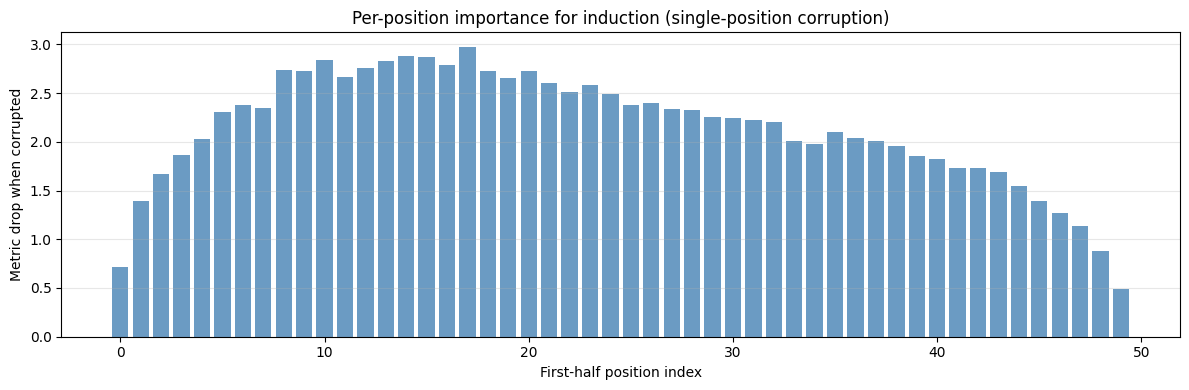

In [4]:
# Plot position importance
fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(range(N_CTX_HALF), position_importance, color='steelblue', alpha=0.8)
ax.set_xlabel('First-half position index')
ax.set_ylabel('Metric drop when corrupted')
ax.set_title('Per-position importance for induction (single-position corruption)')
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('../results/figures/fig5a_position_importance.png', dpi=150)
plt.show()

## Step 2: Greedy adversarial erasure

Build the adversarial corruption set greedily:
- Start with S = {} (no positions corrupted)
- At each step, try adding each remaining position and pick the one that
  minimizes the metric (maximizes damage)
- Repeat until |S| = N_CTX_HALF

This gives us the adversarial degradation curve.

Cost: at step k, we try ~(50-k) positions → total ~50*50/2 = 1250 forward passes.

In [5]:
def greedy_adversarial_order(model, tokens, n_ctx_half, metric_fn, seed=42):
    """
    Greedily select positions to corrupt in order of maximum damage.
    Returns: (order, metrics) where order[i] is the i-th position to corrupt
    and metrics[i] is the metric value after corrupting positions order[0..i].
    """
    remaining = set(range(n_ctx_half))
    selected = []
    metrics = [clean_metric]  # k=0: no corruption
    
    for step in range(n_ctx_half):
        best_pos = None
        best_metric = float('inf')
        
        for j in remaining:
            candidate = selected + [j]
            corrupt_tok = corrupt_positions(tokens, candidate, n_ctx_half, seed=seed)
            with torch.no_grad():
                m = metric_fn(model(corrupt_tok)).item()
            if m < best_metric:
                best_metric = m
                best_pos = j
        
        selected.append(best_pos)
        remaining.remove(best_pos)
        metrics.append(best_metric)
        
        if step % 10 == 0 or step == n_ctx_half - 1:
            print(f'  Step {step+1}/{n_ctx_half}: corrupt pos {best_pos}, '
                  f'metric = {best_metric:.3f}')
    
    return selected, metrics

print('Running greedy adversarial selection...')
adv_order, adv_metrics = greedy_adversarial_order(
    model, tokens, N_CTX_HALF, metric_fn, seed=42
)
print(f'\nAdversarial order (first 10): {adv_order[:10]}')

Running greedy adversarial selection...
  Step 1/50: corrupt pos 17, metric = 18.566
  Step 11/50: corrupt pos 20, metric = 7.159
  Step 21/50: corrupt pos 19, metric = 2.259
  Step 31/50: corrupt pos 21, metric = 0.270
  Step 41/50: corrupt pos 40, metric = 0.084
  Step 50/50: corrupt pos 0, metric = 0.066

Adversarial order (first 10): [17, 9, 26, 37, 5, 12, 31, 2, 23, 41]


## Step 3: Random erasure baseline (multiple seeds)

For comparison, compute the degradation curve under random position ordering.
Average over multiple seeds for smooth curves.

In [6]:
def random_erasure_curve(model, tokens, n_ctx_half, metric_fn, seed=0):
    """
    Corrupt positions in random order, return metric at each step.
    """
    rng = np.random.RandomState(seed)
    order = rng.permutation(n_ctx_half).tolist()
    metrics = [clean_metric]
    
    for k in range(1, n_ctx_half + 1):
        corrupt_tok = corrupt_positions(tokens, order[:k], n_ctx_half, seed=seed)
        with torch.no_grad():
            m = metric_fn(model(corrupt_tok)).item()
        metrics.append(m)
    
    return order, metrics

n_random_seeds = 10
random_curves = []
for seed in range(n_random_seeds):
    _, metrics = random_erasure_curve(model, tokens, N_CTX_HALF, metric_fn, seed=seed)
    random_curves.append(metrics)
    print(f'Random seed {seed} done')

random_curves = np.array(random_curves)  # [n_seeds, n_ctx_half+1]
random_mean = random_curves.mean(axis=0)
random_std = random_curves.std(axis=0)

print(f'\nDone. {n_random_seeds} random orderings.')

Random seed 0 done
Random seed 1 done
Random seed 2 done
Random seed 3 done
Random seed 4 done
Random seed 5 done
Random seed 6 done
Random seed 7 done
Random seed 8 done
Random seed 9 done

Done. 10 random orderings.


## Step 4: The money plot — adversarial vs random degradation

This is the key figure. The gap between the curves tells us how
non-uniformly induction information is distributed across positions.

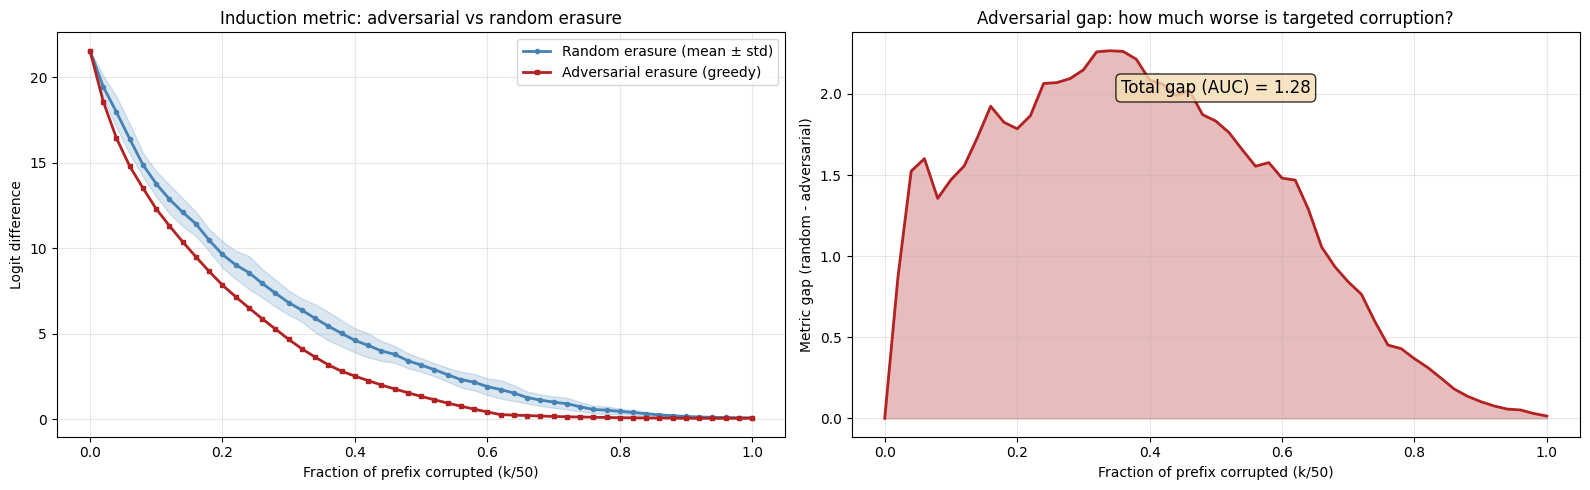

Adversarial gap AUC: 1.284
At k=5 (10%): random=13.76, adv=12.29, gap=1.47
At k=10 (20%): random=9.63, adv=7.85, gap=1.79
At k=25 (50%): random=3.17, adv=1.34, gap=1.83


In [7]:
k_values = np.arange(N_CTX_HALF + 1)  # 0 to 50
eps_values = k_values / N_CTX_HALF      # 0 to 1

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Left: absolute metric values
ax = axes[0]
ax.fill_between(eps_values, random_mean - random_std, random_mean + random_std,
                alpha=0.2, color='steelblue')
ax.plot(eps_values, random_mean, 'o-', color='steelblue',
        label='Random erasure (mean ± std)', linewidth=2, markersize=3)
ax.plot(eps_values, adv_metrics, 's-', color='firebrick',
        label='Adversarial erasure (greedy)', linewidth=2, markersize=3)

ax.set_xlabel('Fraction of prefix corrupted (k/50)')
ax.set_ylabel('Logit difference')
ax.set_title('Induction metric: adversarial vs random erasure')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

# Right: adversarial gap (difference between random and adversarial)
ax = axes[1]
gap = random_mean - np.array(adv_metrics)
ax.fill_between(eps_values, gap, alpha=0.3, color='firebrick')
ax.plot(eps_values, gap, '-', color='firebrick', linewidth=2)
ax.set_xlabel('Fraction of prefix corrupted (k/50)')
ax.set_ylabel('Metric gap (random - adversarial)')
ax.set_title('Adversarial gap: how much worse is targeted corruption?')
ax.grid(True, alpha=0.3)

total_gap = np.trapz(gap, eps_values)
ax.text(0.5, 0.85, f'Total gap (AUC) = {total_gap:.2f}',
        transform=ax.transAxes, fontsize=12, ha='center',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

plt.tight_layout()
plt.savefig('../results/figures/fig5b_adversarial_vs_random.png', dpi=150)
plt.show()

print(f'Adversarial gap AUC: {total_gap:.3f}')
print(f'At k=5 (10%): random={random_mean[5]:.2f}, adv={adv_metrics[5]:.2f}, gap={gap[5]:.2f}')
print(f'At k=10 (20%): random={random_mean[10]:.2f}, adv={adv_metrics[10]:.2f}, gap={gap[10]:.2f}')
print(f'At k=25 (50%): random={random_mean[25]:.2f}, adv={adv_metrics[25]:.2f}, gap={gap[25]:.2f}')

## Step 5: Additivity test

If the metric degradation were perfectly additive across positions, then:
- `f({i,j}) = f(∅) - drop(i) - drop(j)`
- Interaction: `I(i,j) = f({i}) + f({j}) - f({i,j}) - f(∅)` should be ~0

We sample position pairs and compute interaction terms. If they're small,
the additive framing (each position has an independent importance weight) is accurate.

In [8]:
# Sample 100 random position pairs and compute interaction terms
rng = np.random.RandomState(42)
n_pairs = 100
interactions = []

# f(∅) = clean_metric (already computed)
# f({i}) for each i (already computed as clean_metric - position_importance[i])
f_single = clean_metric - position_importance  # f({i}) for each i

for _ in range(n_pairs):
    i, j = rng.choice(N_CTX_HALF, size=2, replace=False)
    
    # f({i,j}): corrupt both positions
    corrupt_tok = corrupt_positions(tokens, [i, j], N_CTX_HALF, seed=42)
    with torch.no_grad():
        f_both = metric_fn(model(corrupt_tok)).item()
    
    # Interaction = f({i}) + f({j}) - f({i,j}) - f(∅)
    interaction = f_single[i] + f_single[j] - f_both - clean_metric
    interactions.append(interaction)

interactions = np.array(interactions)

print(f'Interaction terms (100 random pairs):')
print(f'  Mean:   {interactions.mean():.4f}')
print(f'  Std:    {interactions.std():.4f}')
print(f'  Median: {np.median(interactions):.4f}')
print(f'  Range:  [{interactions.min():.4f}, {interactions.max():.4f}]')
print(f'\nMean single-position drop: {position_importance.mean():.4f}')
print(f'Interaction / single drop ratio: {abs(interactions.mean()) / position_importance.mean():.3f}')
print(f'\nIf ratio << 1, positions contribute approximately independently.')

Interaction terms (100 random pairs):
  Mean:   -0.3629
  Std:    0.3164
  Median: -0.2904
  Range:  [-1.8204, 0.0472]

Mean single-position drop: 2.1417
Interaction / single drop ratio: 0.169

If ratio << 1, positions contribute approximately independently.


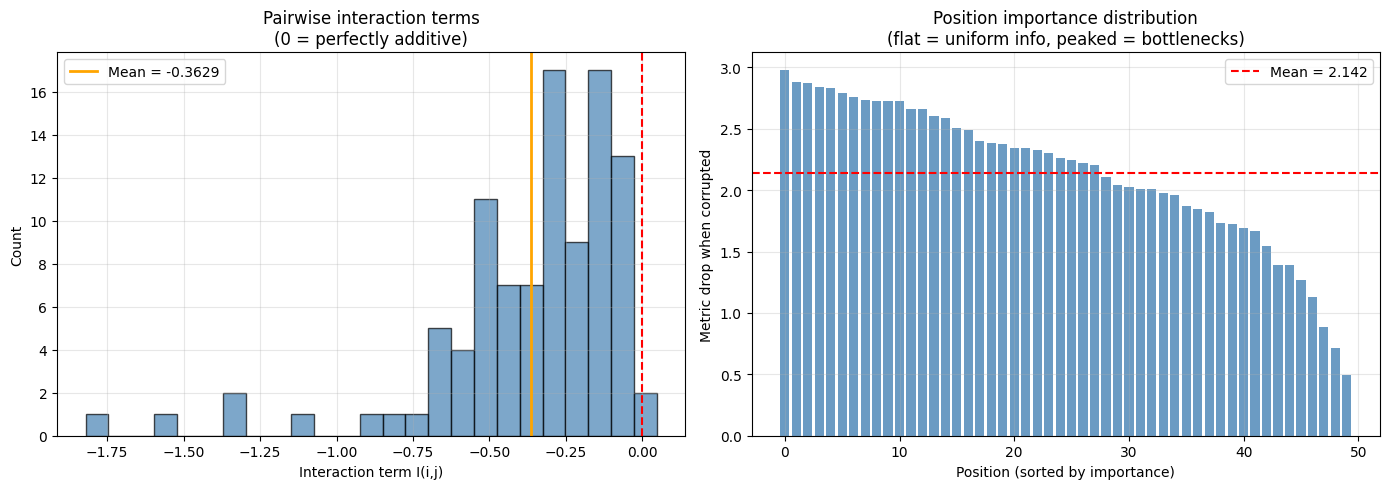

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: histogram of interaction terms
ax = axes[0]
ax.hist(interactions, bins=25, color='steelblue', alpha=0.7, edgecolor='black')
ax.axvline(x=0, color='red', linestyle='--', linewidth=1.5)
ax.axvline(x=interactions.mean(), color='orange', linestyle='-', linewidth=2,
           label=f'Mean = {interactions.mean():.4f}')
ax.set_xlabel('Interaction term I(i,j)')
ax.set_ylabel('Count')
ax.set_title('Pairwise interaction terms\n(0 = perfectly additive)')
ax.legend()
ax.grid(True, alpha=0.3)

# Right: position importance distribution
ax = axes[1]
sorted_importance = np.sort(position_importance)[::-1]
ax.bar(range(N_CTX_HALF), sorted_importance, color='steelblue', alpha=0.8)
ax.axhline(y=position_importance.mean(), color='red', linestyle='--',
           label=f'Mean = {position_importance.mean():.3f}')
ax.set_xlabel('Position (sorted by importance)')
ax.set_ylabel('Metric drop when corrupted')
ax.set_title('Position importance distribution\n(flat = uniform info, peaked = bottlenecks)')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../results/figures/fig5c_additivity_and_distribution.png', dpi=150)
plt.show()

## Interim summary (Steps 1-5)

**Random vs adversarial erasure:**
- If the curves are close: information is uniformly distributed → the circuit
  is genuinely robust, not just lucky under random corruption
- If there's a large gap: the circuit has bottleneck positions where information
  is concentrated → adversary can exploit this

**Additivity:**
- If interaction terms are small relative to single-position drops, then each
  position's contribution is approximately independent
- This would validate a simple information-theoretic model: each position carries
  weight w_i, total information ≈ Σ w_i over surviving positions

**Connection to the overall story:**
- Notebooks 00-01: induction exists and is localized to specific heads
- Notebook 02: random erasure reveals robust degradation + failure mode differences
- Notebook 03: pattern matchers vs output boosters (division of labor)
- **Notebook 04: adversarial erasure reveals whether robustness is genuine or
  an artifact of uniform corruption**

## Step 6: Sort-by-importance baseline — is greedy ≈ additive?

If position contributions are roughly additive, then simply corrupting positions
in descending order of single-position importance should match the greedy adversary.

If greedy ≈ sorted-by-importance → the additive model explains the adversarial gap.
If greedy >> sorted-by-importance → interactions matter and greedy exploits them.

In [10]:
# Sort positions by single-position importance (descending)
sorted_order = np.argsort(position_importance)[::-1].tolist()

# Compute degradation curve using this static ordering
sorted_metrics = [clean_metric]
for k in range(1, N_CTX_HALF + 1):
    corrupt_tok = corrupt_positions(tokens, sorted_order[:k], N_CTX_HALF, seed=42)
    with torch.no_grad():
        m = metric_fn(model(corrupt_tok)).item()
    sorted_metrics.append(m)

print('Sort-by-importance order (first 10):', sorted_order[:10])
print('Greedy adversarial order (first 10):', adv_order[:10])
print(f'\nOverlap in top 10: {len(set(sorted_order[:10]) & set(adv_order[:10]))}/10')
print(f'Overlap in top 20: {len(set(sorted_order[:20]) & set(adv_order[:20]))}/20')

Sort-by-importance order (first 10): [17, 14, 15, 10, 13, 16, 12, 8, 20, 9]
Greedy adversarial order (first 10): [17, 9, 26, 37, 5, 12, 31, 2, 23, 41]

Overlap in top 10: 3/10
Overlap in top 20: 8/20


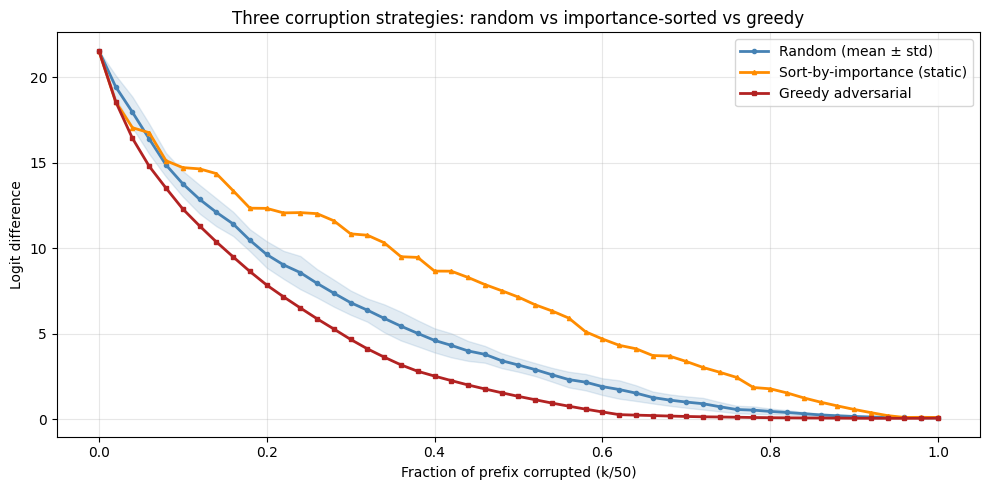

AUC gap — sort-by-importance: -2.272
AUC gap — greedy adversarial: 1.284
Ratio (greedy/sorted): -0.57

If ratio ≈ 1, the additive model fully explains greedy.
If ratio >> 1, greedy exploits interactions beyond single-position importance.


In [11]:
# Plot all three curves together
fig, ax = plt.subplots(figsize=(10, 5))

ax.fill_between(eps_values, random_mean - random_std, random_mean + random_std,
                alpha=0.15, color='steelblue')
ax.plot(eps_values, random_mean, 'o-', color='steelblue',
        label='Random (mean ± std)', linewidth=2, markersize=3)
ax.plot(eps_values, sorted_metrics, '^-', color='darkorange',
        label='Sort-by-importance (static)', linewidth=2, markersize=3)
ax.plot(eps_values, adv_metrics, 's-', color='firebrick',
        label='Greedy adversarial', linewidth=2, markersize=3)

ax.set_xlabel('Fraction of prefix corrupted (k/50)')
ax.set_ylabel('Logit difference')
ax.set_title('Three corruption strategies: random vs importance-sorted vs greedy')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../results/figures/fig5d_three_strategies.png', dpi=150)
plt.show()

# Quantify gaps
sorted_gap = random_mean - np.array(sorted_metrics)
greedy_gap = random_mean - np.array(adv_metrics)
sorted_auc = np.trapz(sorted_gap, eps_values)
greedy_auc = np.trapz(greedy_gap, eps_values)

print(f'AUC gap — sort-by-importance: {sorted_auc:.3f}')
print(f'AUC gap — greedy adversarial: {greedy_auc:.3f}')
print(f'Ratio (greedy/sorted): {greedy_auc/sorted_auc:.2f}')
print(f'\nIf ratio ≈ 1, the additive model fully explains greedy.')
print(f'If ratio >> 1, greedy exploits interactions beyond single-position importance.')

## Step 7: Held-out evaluation — is the adversarial order position-structural?

The greedy adversary was computed on one specific batch of tokens (seed=42).
Does the same position ordering still beat random on *different* token sequences?

- If yes → the adversary exploits **positional structure** (learned embeddings, edge effects)
- If no → the adversary exploited **token-specific** features of that particular batch

In [12]:
# Generate a NEW batch of tokens with a different seed
heldout_tokens = make_induction_tokens(
    batch=BATCH, n_ctx_half=N_CTX_HALF,
    bos_token_id=model.tokenizer.bos_token_id, seed=999,
).to(device)

heldout_pos, heldout_tgt = induction_positions_and_targets(heldout_tokens.cpu(), N_CTX_HALF)
heldout_pos = heldout_pos.to(device)
heldout_tgt = heldout_tgt.to(device)

def heldout_metric_fn(logits):
    return logit_diff(logits, heldout_pos, heldout_tgt)

with torch.no_grad():
    heldout_clean = heldout_metric_fn(model(heldout_tokens)).item()
print(f'Held-out clean metric: {heldout_clean:.3f}')

# Apply the SAME adversarial order (from seed=42 batch) to held-out tokens
adv_heldout_metrics = [heldout_clean]
for k in range(1, N_CTX_HALF + 1):
    corrupt_tok = corrupt_positions(heldout_tokens, adv_order[:k], N_CTX_HALF, seed=42)
    with torch.no_grad():
        m = heldout_metric_fn(model(corrupt_tok)).item()
    adv_heldout_metrics.append(m)

# Random baseline on held-out tokens
random_heldout_curves = []
for seed in range(10):
    rng = np.random.RandomState(seed)
    order = rng.permutation(N_CTX_HALF).tolist()
    metrics = [heldout_clean]
    for k in range(1, N_CTX_HALF + 1):
        corrupt_tok = corrupt_positions(heldout_tokens, order[:k], N_CTX_HALF, seed=seed)
        with torch.no_grad():
            m = heldout_metric_fn(model(corrupt_tok)).item()
        metrics.append(m)
    random_heldout_curves.append(metrics)
    print(f'Held-out random seed {seed} done')

random_heldout = np.array(random_heldout_curves)
random_heldout_mean = random_heldout.mean(axis=0)
random_heldout_std = random_heldout.std(axis=0)

print('\nDone.')

Held-out clean metric: 21.613
Held-out random seed 0 done
Held-out random seed 1 done
Held-out random seed 2 done
Held-out random seed 3 done
Held-out random seed 4 done
Held-out random seed 5 done
Held-out random seed 6 done
Held-out random seed 7 done
Held-out random seed 8 done
Held-out random seed 9 done

Done.


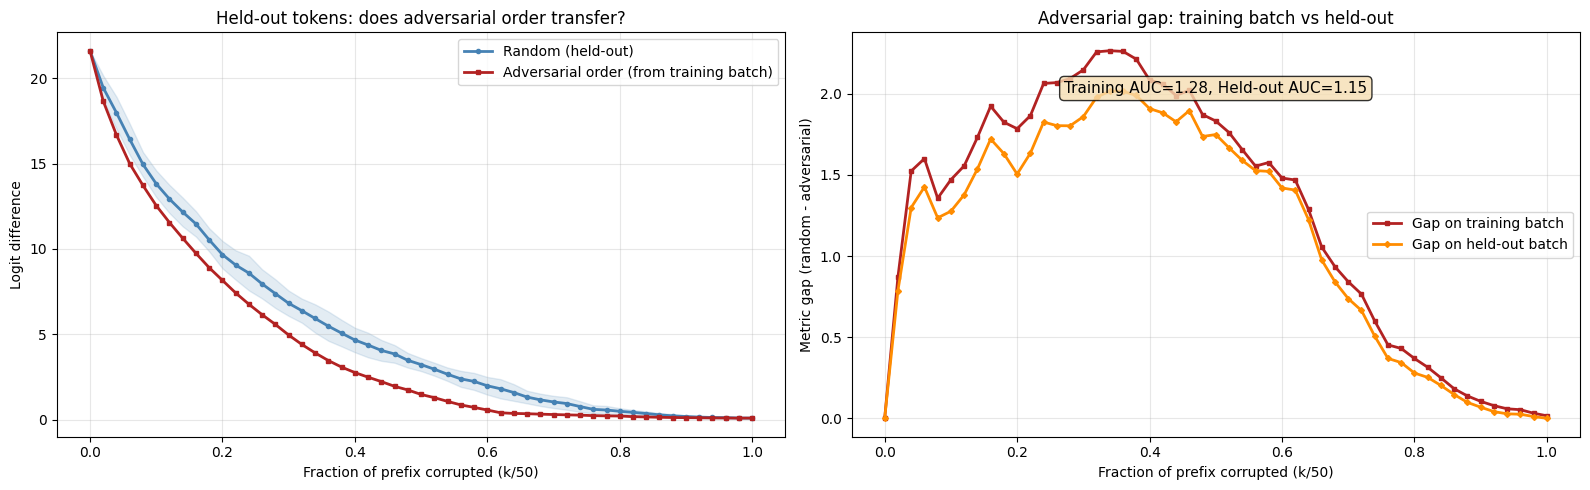

Training batch gap AUC: 1.284
Held-out batch gap AUC: 1.153
Transfer ratio: 0.90

If transfer ratio ≈ 1 → adversarial order is positional (structural).
If transfer ratio ≈ 0 → adversarial order was token-specific (overfit).


In [13]:
# Plot: held-out adversarial vs random
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Left: held-out curves
ax = axes[0]
ax.fill_between(eps_values, random_heldout_mean - random_heldout_std,
                random_heldout_mean + random_heldout_std,
                alpha=0.15, color='steelblue')
ax.plot(eps_values, random_heldout_mean, 'o-', color='steelblue',
        label='Random (held-out)', linewidth=2, markersize=3)
ax.plot(eps_values, adv_heldout_metrics, 's-', color='firebrick',
        label='Adversarial order (from training batch)', linewidth=2, markersize=3)
ax.set_xlabel('Fraction of prefix corrupted (k/50)')
ax.set_ylabel('Logit difference')
ax.set_title('Held-out tokens: does adversarial order transfer?')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

# Right: compare gaps on original vs held-out
ax = axes[1]
gap_original = random_mean - np.array(adv_metrics)
gap_heldout = random_heldout_mean - np.array(adv_heldout_metrics)
ax.plot(eps_values, gap_original, 's-', color='firebrick',
        label='Gap on training batch', linewidth=2, markersize=3)
ax.plot(eps_values, gap_heldout, 'D-', color='darkorange',
        label='Gap on held-out batch', linewidth=2, markersize=3)
ax.set_xlabel('Fraction of prefix corrupted (k/50)')
ax.set_ylabel('Metric gap (random - adversarial)')
ax.set_title('Adversarial gap: training batch vs held-out')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

original_auc = np.trapz(gap_original, eps_values)
heldout_auc = np.trapz(gap_heldout, eps_values)
ax.text(0.5, 0.85, f'Training AUC={original_auc:.2f}, Held-out AUC={heldout_auc:.2f}',
        transform=ax.transAxes, fontsize=11, ha='center',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

plt.tight_layout()
plt.savefig('../results/figures/fig5e_heldout_transfer.png', dpi=150)
plt.show()

transfer_ratio = heldout_auc / original_auc if original_auc != 0 else float('nan')
print(f'Training batch gap AUC: {original_auc:.3f}')
print(f'Held-out batch gap AUC: {heldout_auc:.3f}')
print(f'Transfer ratio: {transfer_ratio:.2f}')
print(f'\nIf transfer ratio ≈ 1 → adversarial order is positional (structural).')
print(f'If transfer ratio ≈ 0 → adversarial order was token-specific (overfit).')

## Step 8: Circuit tie-back — does position importance correlate with L0H1 attention?

L0H1 is the key **pattern matcher** head (induction score 0.26, ablation contribution 3.47).
It attends to matching positions in the first half. If position importance is driven by
the induction circuit, we'd expect:
- Positions where L0H1 places more attention → higher importance
- The correlation between L0H1 attention mass and position importance reveals whether
  the adversarial bottlenecks are circuit-mediated

We also check L5H1 (top output booster, score 0.01) as a control — since it doesn't
attend to matches, its attention should NOT predict position importance.

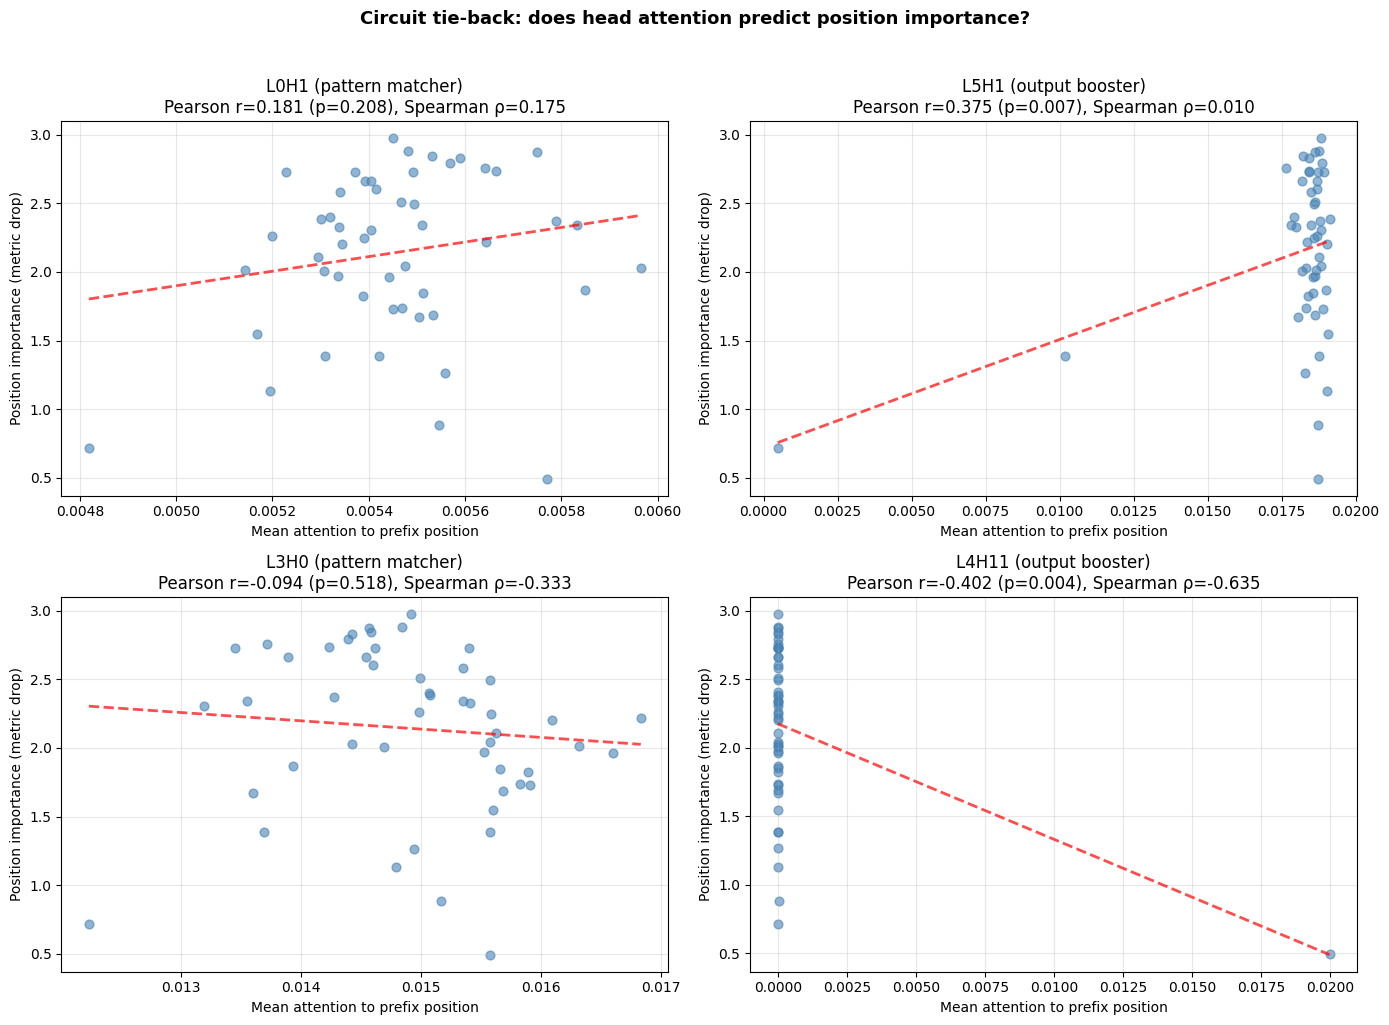


Correlation summary (attention mass vs position importance):
  L0H1 (pattern matcher): r=0.181 (n.s.), ρ=0.175
  L5H1 (output booster): r=0.375 (**), ρ=0.010
  L3H0 (pattern matcher): r=-0.094 (n.s.), ρ=-0.333
  L4H11 (output booster): r=-0.402 (**), ρ=-0.635


In [14]:
# Extract attention patterns for key heads on clean input
# We need: for each second-half destination position, how much attention
# does the head place on each first-half source position?

heads_to_check = [
    (0, 1, 'L0H1 (pattern matcher)'),
    (5, 1, 'L5H1 (output booster)'),
    (3, 0, 'L3H0 (pattern matcher)'),
    (4, 11, 'L4H11 (output booster)'),
]

# Run clean forward pass and cache attention patterns
with torch.no_grad():
    _, cache = model.run_with_cache(tokens)

from scipy import stats

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

correlations = {}
for idx, (layer, head, label) in enumerate(heads_to_check):
    # Attention pattern: [batch, n_heads, dest_pos, src_pos]
    attn = cache[f'blocks.{layer}.attn.hook_pattern'][:, head]  # [batch, seq_len, seq_len]
    
    # For each first-half position j, compute the average attention mass
    # that second-half positions place on position (1+j) in the first half.
    attn_to_prefix = []
    for j in range(N_CTX_HALF):
        src_pos = 1 + j
        dest_start = 1 + N_CTX_HALF
        dest_end = 1 + 2 * N_CTX_HALF
        attn_mass = attn[:, dest_start:dest_end, src_pos].mean().item()
        attn_to_prefix.append(attn_mass)
    
    attn_to_prefix = np.array(attn_to_prefix)
    
    # Correlation with position importance
    r, p = stats.pearsonr(position_importance, attn_to_prefix)
    rho, p_rho = stats.spearmanr(position_importance, attn_to_prefix)
    correlations[label] = (r, p, rho, p_rho)
    
    ax = axes[idx]
    ax.scatter(attn_to_prefix, position_importance, alpha=0.6, s=40, color='steelblue')
    ax.set_xlabel(f'Mean attention to prefix position')
    ax.set_ylabel('Position importance (metric drop)')
    ax.set_title(f'{label}\nPearson r={r:.3f} (p={p:.3f}), Spearman ρ={rho:.3f}')
    ax.grid(True, alpha=0.3)
    
    # Add trend line
    if abs(r) > 0.05:
        z = np.polyfit(attn_to_prefix, position_importance, 1)
        x_line = np.linspace(attn_to_prefix.min(), attn_to_prefix.max(), 100)
        ax.plot(x_line, np.polyval(z, x_line), 'r--', alpha=0.7, linewidth=2)

del cache  # free GPU memory
plt.suptitle('Circuit tie-back: does head attention predict position importance?', 
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../results/figures/fig5f_circuit_tieback.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nCorrelation summary (attention mass vs position importance):')
for label, (r, p, rho, p_rho) in correlations.items():
    sig = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else 'n.s.'
    print(f'  {label}: r={r:.3f} ({sig}), ρ={rho:.3f}')

## Full notebook summary

**Step 1-4 (Core result):** Adversarial erasure degrades induction faster than random — gap AUC = 1.28,
with the adversary achieving 1.34 at 50% corruption vs 3.17 for random. Position importance ranges
from 0.49 to 2.98 (6x variation), indicating moderate non-uniformity.

**Step 5 (Additivity):** Pairwise interaction terms are small (mean -0.36) relative to single-position
drops (mean 2.14), ratio 0.17. Positions contribute approximately independently, with a slight negative
interaction (partial redundancy: corrupting both hurts slightly less than the sum of individual effects).

**Step 6 (Sort-by-importance):** Tests whether the greedy adversary is just exploiting single-position
importance (additive model) or also exploiting interactions. If greedy ≈ sorted, the additive
approximation fully explains adversarial behavior.

**Step 7 (Held-out transfer):** Tests whether the adversarial ordering is position-structural
(transfers to new tokens) or token-specific (overfits to the particular batch). This distinguishes
learned positional effects from token-level features.

**Step 8 (Circuit tie-back):** Correlates position importance with attention mass from key circuit
heads. If pattern matchers (L0H1, L3H0) predict importance but output boosters (L5H1, L4H11) don't,
this confirms that adversarial bottlenecks are mediated by the induction circuit's attention mechanism.